What is the price distribution of menu items?

In [133]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import MarkerCluster # библиотека для создания интерактивных карт
conn = sqlite3.connect('data/takeaway.db')

## Query 6: Where are the delivery ‘dead zones’ — areas with minimal restaurant coverage?

In [134]:
query= """
SELECT l.postalCode,
       l.city,
       COUNT(r.primarySlug) AS restaurant_count,
       MIN(l.latitude) AS latitude,
       MIN(l.longitude) AS longitude
FROM restaurants r
JOIN locations_to_restaurants ltr 
    ON r.primarySlug = ltr.restaurant_id
JOIN locations l 
    ON l.id = ltr.location_id
GROUP BY l.postalCode, l.city
ORDER BY restaurant_count ASC, l.postalCode ASC;
"""

deadzone_city_postal_df = pd.read_sql_query(query, conn)
deadzone_city_postal_df.head()

,postalCode,city,restaurant_count,latitude,longitude
0,8640,Oostvleteren,1,50.933785,2.741783
1,8640,Woesten,1,50.900635,2.790450
2,8647,Noordschote,1,50.955238,2.810721
3,8647,Pollinkhove,1,50.970816,2.733174
4,8647,Reninge,1,50.947662,2.789880


In [135]:
map_center = [deadzone_city_postal_df['latitude'].mean(), deadzone_city_postal_df['longitude'].mean()]
m = folium.Map(location=map_center, zoom_start=10)

marker_cluster = MarkerCluster().add_to(m)

for idx, row in deadzone_city_postal_df.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5 + row['restaurant_count'],
        color='red',
        fill=True,
        fill_color='red',
        fill_opacity=0.6,
        popup=f"City: {row['city']}<br>"
              f"PostalCode: {row['postalCode']}<br>"
              f"Restaurants: {row['restaurant_count']}"
    ).add_to(marker_cluster)

m.save("maps/dead_zones_map.html")

#### Top-20 "dead-zones" (bar chart)

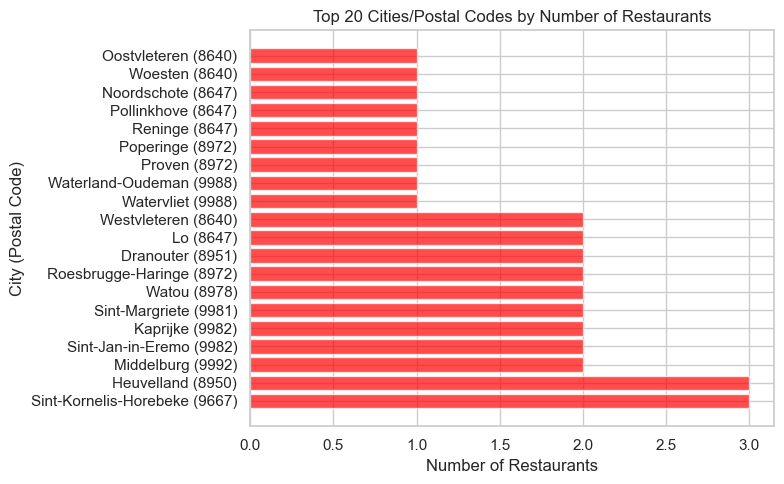

In [136]:
query_top20 = """
SELECT 
    l.postalCode,
    l.city,
    COUNT(r.primarySlug) AS restaurant_count,
    MIN(l.latitude) AS latitude,
    MIN(l.longitude) AS longitude
FROM restaurants r
JOIN locations_to_restaurants ltr 
    ON r.primarySlug = ltr.restaurant_id
JOIN locations l 
    ON l.id = ltr.location_id
GROUP BY l.postalCode, l.city
ORDER BY restaurant_count ASC
LIMIT 20;
"""

top20_df = pd.read_sql_query(query_top20, conn)

top20_df['label'] = top20_df['city'] + " (" + top20_df['postalCode'].astype(str) + ")"

plt.figure(figsize=(8,5))

plt.barh(top20_df['label'][::-1], top20_df['restaurant_count'][::-1], color='red', alpha=0.7)
plt.xlabel("Number of Restaurants")
plt.ylabel("City (Postal Code)")
plt.title("Top 20 Cities/Postal Codes by Number of Restaurants")
plt.tight_layout()
plt.savefig('graphs/plot_q6.png', bbox_inches='tight', dpi=300)
plt.show()

## Query 7: How does the availability of vegetarian and vegan dishes vary by area?

In [137]:
query_city = """
SELECT 
    r.city,
    COUNT(DISTINCT r.primarySlug) AS veg_restaurant_count,
    AVG(m.price) AS avg_veg_price,
    GROUP_CONCAT(DISTINCT r.name) AS restaurants,
    GROUP_CONCAT(DISTINCT m.name) AS veg_items,
    AVG(r.latitude) AS lat,
    AVG(r.longitude) AS lon
FROM restaurants r
JOIN menuItems m
    ON r.primarySlug = m.primarySlug
WHERE LOWER(m.name) LIKE '%veg%'
  AND LOWER(m.name) NOT LIKE '%non%'
GROUP BY r.city
ORDER BY r.city;
"""

df_city = pd.read_sql_query(query_city, conn)
df_city.head()

,city,veg_restaurant_count,avg_veg_price,restaurants,veg_items,lat,lon
0,1040,1,12.000000,Snack Thieffry,Menu bicky burger 100% vegetarien avec pain ar...,50.830792,4.399869
1,Aalst,29,9.401399,"Fistro,Frituur Anita,Frituur Mijlbeek,Pitta Mo...","Vegan goulash,Vegan seitan stew,Vegan groenten...",50.942663,4.039468
2,Aalter,3,9.541667,"Pizza Valo,Pita Pizza Pyramide,Njam Njam Pizza","Pizza vegetarisch (small),Pizza vegetarisch (m...",51.088105,3.447887
3,Aarschot,8,9.675000,"Istanbul Grill Huis,Efes bij Carlos Niko,De Ec...","Vegetariana,Spaghetti vegetarisch,Broodje vege...",50.989690,4.834420
4,Aarstelaar,1,14.128571,Mati Sushi,"Veggie combo,Veggie sushi boot (2 pers),Veg re...",51.134349,4.387790


In [152]:
from branca.colormap import linear
m = folium.Map(
    location=[df_city.lat.mean(), df_city.lon.mean()],
    zoom_start=6,
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
    attr='Esri'
)

colormap = linear.YlGn_09.scale(
    df_city.veg_restaurant_count.min(),
    df_city.veg_restaurant_count.max()
)
colormap.caption = "Veg Restaurant Density by City"
colormap.add_to(m)


for _, row in df_city.iterrows():
    folium.CircleMarker(
        location=[row.lat, row.lon],
        radius=6 + row.veg_restaurant_count * 0.2,  
        color=colormap(row.veg_restaurant_count),
        fill=True,
        fill_color=colormap(row.veg_restaurant_count),
        fill_opacity=0.7,
        popup=folium.Popup(f"""
            <b>{row.city}</b><br>
            Veg Restaurants: {row.veg_restaurant_count}<br>
            Avg Price: {row.avg_veg_price:.2f}<br>
            <b>Restaurants:</b> {row.restaurants}<br>
            <b>Veg Items:</b> {row.veg_items}
        """, max_width=400)
    ).add_to(m)

m.save("maps/veg_restaurant_map.html")


#### Top-20 cities with the highest veg restaurant density (horizontal bar chart)

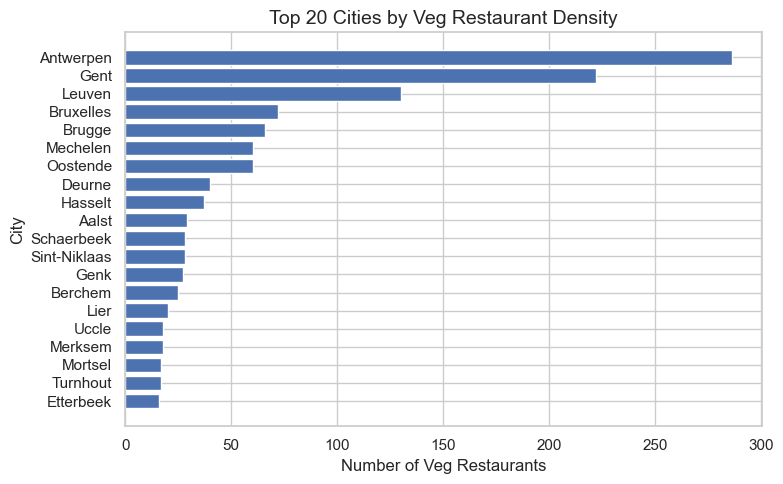

In [139]:
top_cities = df_city.sort_values('veg_restaurant_count', ascending=False).head(20)

plt.figure(figsize=(8,5))

norm = top_cities['veg_restaurant_count'] / top_cities['veg_restaurant_count'].max()
colors = plt.cm.YlGn(norm)  

plt.barh(
    top_cities['city'][::-1], 
    top_cities['veg_restaurant_count'][::-1],
    # color=colors[::-1] 
)

plt.xlabel("Number of Veg Restaurants")
plt.ylabel("City")
plt.title("Top 20 Cities by Veg Restaurant Density", fontsize=14)
plt.tight_layout()
plt.savefig('graphs/plot_q7.png', bbox_inches='tight', dpi=300)
plt.show()

## Query 8: Identify the World Hummus Order (WHO); top-3 hummus serving restaurants

In [140]:
query = """
SELECT *
FROM (
    SELECT r.primarySlug,
           r.name,
           GROUP_CONCAT(LOWER(m.name), ', ') AS hummus_items,
           r.city,
           r.ratings,
           r.ratingsNumber,
           r.deliveryFee,
           r.durationRangeMin,
           r.durationRangeMax
    FROM restaurants r
    JOIN menuItems m
      ON r.primarySlug = m.primarySlug 
    WHERE LOWER(m.name) LIKE '%hummus%'
    GROUP BY r.primarySlug, r.name, r.city, r.ratings, r.ratingsNumber, r.deliveryFee, r.durationRangeMin, r.durationRangeMax
    ORDER BY r.ratingsNumber DESC
    LIMIT 50
) AS top_votes
WHERE ratings >= 4.5
ORDER BY ratings DESC
LIMIT 3;
"""
top_3_hummus = pd.read_sql_query(query, conn)
top_3_hummus

,primarySlug,name,hummus_items,city,ratings,ratingsNumber,deliveryFee,durationRangeMin,durationRangeMax
0,restaurant-le-royal,Restaurant le Royal,"hummus, hummus bi lahme",Bruxelles-Capitale,5.0,359,5.0,30,55
1,royal-donuts-bagels-maasmechelen,Royal Donuts & Bagels,bagel hummus,Maasmechelen,5.0,94,4.0,20,45
2,the-black-horse,The Black Horse,"hummus (pita), hummus (minischotel), hummus (m...",Heist-op-den-Berg,4.9,127,0.0,10,20


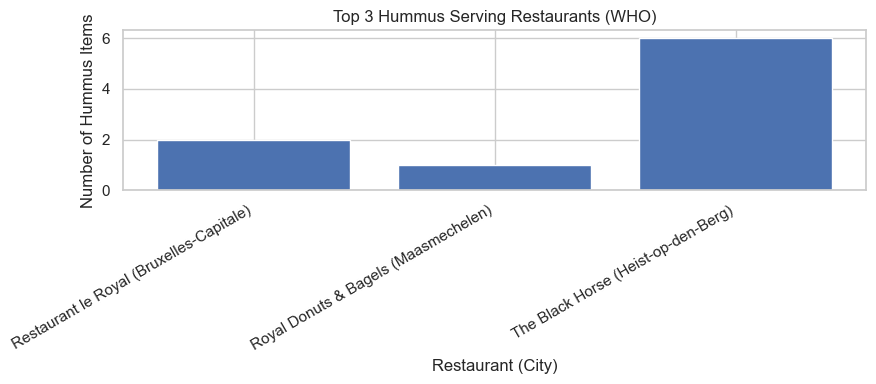

In [141]:
top_3_hummus['label'] = top_3_hummus['name'] + " (" + top_3_hummus['city'] + ")"
top_3_hummus['hummus_count'] = top_3_hummus['hummus_items'].apply(lambda x: len(x.split(', ')))

plt.figure(figsize=(9, 4))

plt.bar(
    top_3_hummus['label'],
    top_3_hummus['hummus_count']
)

plt.xlabel('Restaurant (City)')
plt.ylabel('Number of Hummus Items')
plt.title('Top 3 Hummus Serving Restaurants (WHO)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('graphs/plot_q8.png', bbox_inches='tight', dpi=300)
plt.show()

## Query 9: Average number of restaurants per 100000 residents by province

In [142]:
df_population = pd.read_excel('data/population_belgium.xlsx')
# df_population['population'] = pd.to_numeric(df_population['population'], errors='coerce')

df_population.dtypes

postcode_range    object
postcode_start     int64
postcode_end       int64
region            object
main_city         object
population         int64
dtype: object

In [143]:
df_population.to_sql('pop_table', conn, if_exists='replace', index=False)
query = """
SELECT 
    p.region,
    COUNT(DISTINCT r.primarySlug) AS total_restaurants,
    p.population,
    (CAST(COUNT(DISTINCT r.primarySlug) AS FLOAT) / p.population) * 1000 AS restaurants_per_1000_people
FROM restaurants r
JOIN locations_to_restaurants lr ON r.primarySlug = lr.restaurant_id
JOIN locations l ON lr.location_id = l.ID
JOIN pop_table p
    ON CAST(l.postalCode AS INTEGER) BETWEEN p.postcode_start AND p.postcode_end
GROUP BY p.region, p.population
ORDER BY restaurants_per_1000_people DESC;
"""
rest_per_province = pd.read_sql_query(query, conn)
rest_per_province['restaurants_per_1000_people'] = rest_per_province['restaurants_per_1000_people'].round(2)
rest_per_province 

,region,total_restaurants,population,restaurants_per_1000_people
0,Flemish_Brabant_West,1157,662500,1.75
1,Flemish_Brabant_East,485,542041,0.89
2,Antwerp,1186,1921189,0.62
3,Brussels,605,1255795,0.48
4,East_Flanders,752,1602532,0.47
5,Limburg,344,904919,0.38
6,West_Flanders,444,1231585,0.36
7,Walloon_Brabant,8,415381,0.02


C:\Users\Becode\AppData\Local\Temp\ipykernel_7664\56094621.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


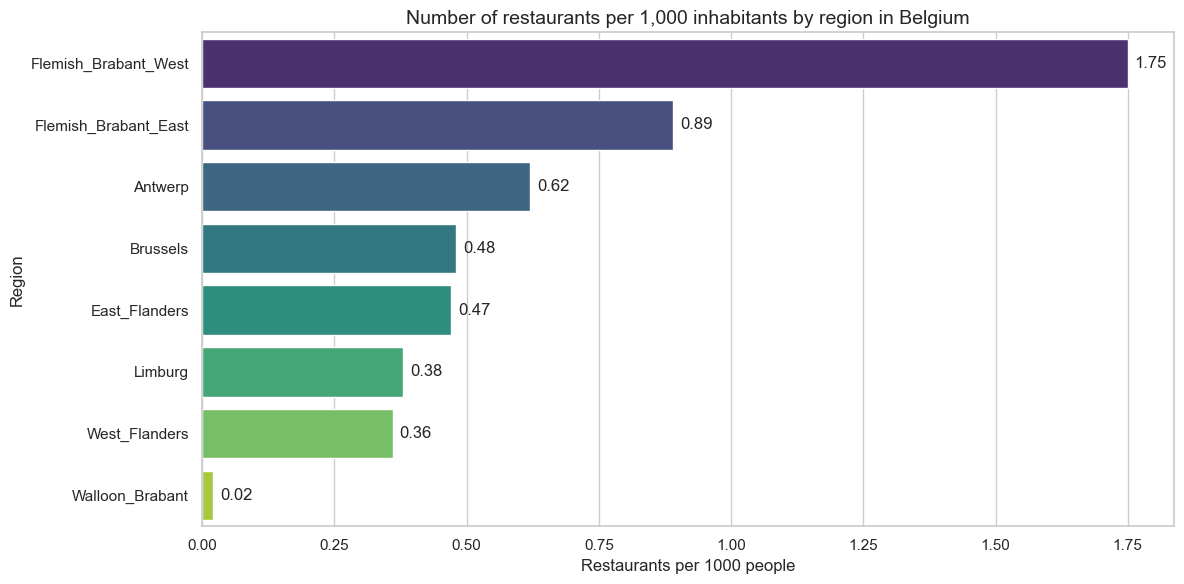

In [144]:
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=rest_per_province, 
    x='restaurants_per_1000_people', 
    y='region', 
    palette='viridis'
)

for i in ax.containers:
    ax.bar_label(i, padding=5)

plt.title('Number of restaurants per 1,000 inhabitants by region in Belgium', fontsize=14)
plt.xlabel('Restaurants per 1000 people', fontsize=12)
plt.ylabel('Region', fontsize=12)
plt.tight_layout()
plt.savefig('graphs/plot_q9.png', bbox_inches='tight', dpi=300)
plt.show()

## Query 10: Top-5 Leuven restaurants with ratings above 4 and the fastest delivery

In [145]:
query = """
SELECT 
    name, 
    ratings, 
    durationRangeMin, 
    deliveryFee,
    primarySlug
FROM restaurants
WHERE city = 'Leuven' 
  AND ratings > 4.0
  AND (name LIKE '%Sush%' OR primarySlug LIKE '%sush%')
ORDER BY durationRangeMin ASC, ratings DESC
LIMIT 5;
"""
Leuven_sushi = pd.read_sql_query(query, conn)
Leuven_sushi

,name,ratings,durationRangeMin,deliveryFee,primarySlug
0,You Sushi,4.3,20,0.00,you-sushi-leuven-1
1,Hokkaido Sushi,4.2,20,0.00,hokkaido-sushi
2,Sushi Mama,4.6,30,0.00,sushi-mama
3,Soroki - Sushi & Wok,4.1,35,3.99,soroki-sushi
4,Fuji Sushi,4.7,40,2.99,fuji-sushi


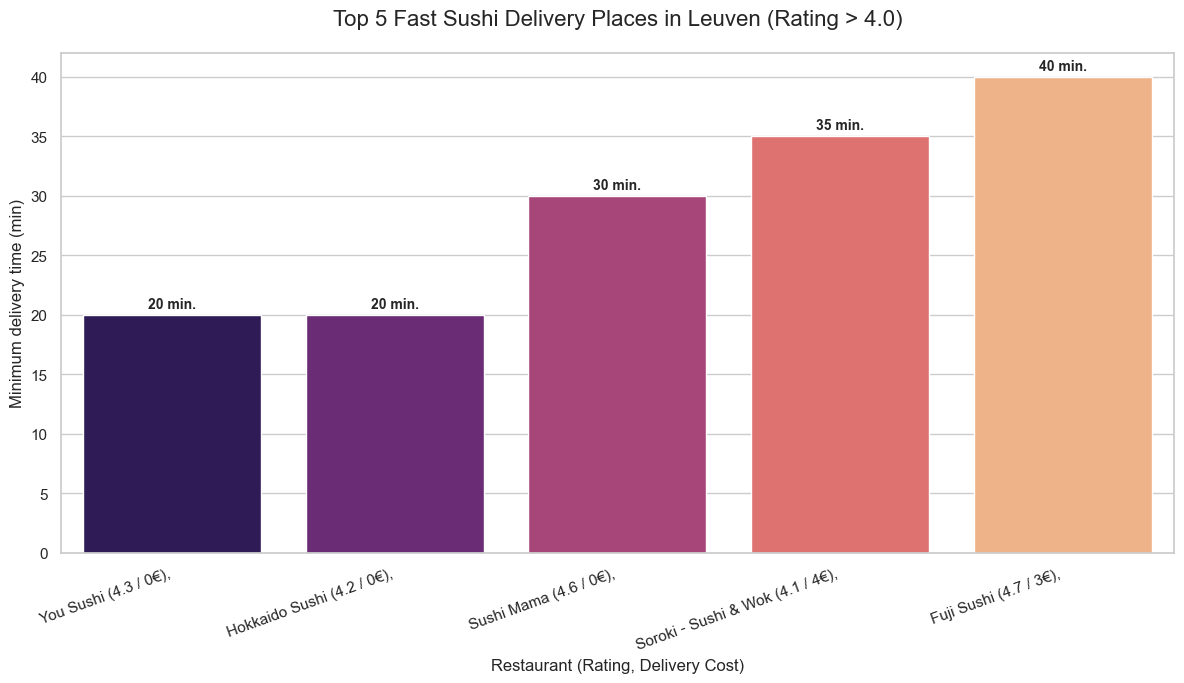

In [146]:
Leuven_sushi['x_label'] = (Leuven_sushi['name'] + ' (' + Leuven_sushi['ratings'].astype(str) + ' / '+ Leuven_sushi['deliveryFee'].round(0).astype(int).astype(str) + '€'+ '),')

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

plot = sns.barplot(
    data=Leuven_sushi, 
    x='x_label', 
    y='durationRangeMin', 
    hue='x_label',    
    legend=False,     
    palette='magma'
)

for container in plot.containers:
    plot.bar_label(container, fmt='%d min.', padding=3, fontsize=10, fontweight='bold')

plt.title('Top 5 Fast Sushi Delivery Places in Leuven (Rating > 4.0)', fontsize=16, pad=20)
plt.xlabel('Restaurant (Rating, Delivery Cost)', fontsize=12)
plt.ylabel('Minimum delivery time (min)', fontsize=12)

plt.xticks(rotation=20, ha='right')

plt.tight_layout()
plt.savefig('graphs/plot_q10.png', bbox_inches='tight', dpi=300)
plt.show()